# 02 Tracks EDA

This notebook explores the `tracks` table in more detail.  
The goal is to understand the main track-level variables before we later combine the datasets for feature engineering and recommendations.

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

## 1. Load Tracks Data

We first load the tracks table from DuckDB and check the basic shape of the dataset.

In [2]:
tracks = con.execute("SELECT * FROM tracks").df()

tracks.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(101939, 32)

In [3]:
tracks.head()

,column00,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,...,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
0,0,0.294,0D3QufeCudpQANOR7luqdr,https://api.spotify.com/v1/audio-analysis/5qlj...,['3mxJuHRn2ZWD5OofvJtDZY'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.698,1.0,235584.0,...,https://p.scdn.co/mp3-preview/1b05a902da3a251d...,0.0262,115.018,4.0,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_14,1.0,spotify:track:5qljLQuKnNJf4F4vfxQB0V,0.6220,track
1,1,0.863,1bcqsH5UyTBzmh9YizdsBE,https://api.spotify.com/v1/audio-analysis/3VAX...,['4xWMewm6CYMstu0sPgd9jJ'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,656960.0,...,https://p.scdn.co/mp3-preview/d8140736a6131cb5...,0.9220,115.075,3.0,https://api.spotify.com/v1/tracks/3VAX2MJdmdqA...,track_3,3.0,spotify:track:3VAX2MJdmdqARLSU5hPMpm,0.5890,track
2,2,0.750,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1L3Y...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.466,1.0,492840.0,...,https://p.scdn.co/mp3-preview/c8af28fb15185b18...,0.9440,79.565,4.0,https://api.spotify.com/v1/tracks/1L3YAhsEMrGV...,track_4,4.0,spotify:track:1L3YAhsEMrGVvCgDXj2TYn,0.0850,track
3,3,0.763,6FeJF5r8roonnKraJxr4oB,https://api.spotify.com/v1/audio-analysis/6aCe...,['2KQsUB9DRBcJk17JWX1eXD'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,316578.0,...,https://p.scdn.co/mp3-preview/7629b8e9f31f6e9b...,0.9380,112.822,3.0,https://api.spotify.com/v1/tracks/6aCe9zzoZmCo...,track_9,1.0,spotify:track:6aCe9zzoZmCojX7bbgKKtf,0.5330,track
4,4,0.770,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1Vo8...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.460,1.0,558880.0,...,https://p.scdn.co/mp3-preview/32be593c0eb82868...,0.9430,81.260,4.0,https://api.spotify.com/v1/tracks/1Vo802A38tPF...,track_2,2.0,spotify:track:1Vo802A38tPFHmje1h91um,0.0906,track


In [4]:
tracks.columns.tolist()

['column00',
 'acousticness',
 'album_id',
 'analysis_url',
 'artists_id',
 'available_markets',
 'country',
 'danceability',
 'disc_number',
 'duration_ms',
 'energy',
 'href',
 'id',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'lyrics',
 'mode',
 'name',
 'playlist',
 'popularity',
 'preview_url',
 'speechiness',
 'tempo',
 'time_signature',
 'track_href',
 'track_name_prev',
 'track_number',
 'uri',
 'valence',
 'type']

## 2. Basic Dataset Information

This gives a first overview of column types and missing values.

In [5]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101939 entries, 0 to 101938
Data columns (total 32 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   column00           101939 non-null  int64  
 1   acousticness       101939 non-null  float64
 2   album_id           101939 non-null  object 
 3   analysis_url       101939 non-null  object 
 4   artists_id         101939 non-null  object 
 5   available_markets  101939 non-null  object 
 6   country            101939 non-null  object 
 7   danceability       101939 non-null  float64
 8   disc_number        101939 non-null  float64
 9   duration_ms        101939 non-null  float64
 10  energy             101939 non-null  float64
 11  href               101939 non-null  object 
 12  id                 101939 non-null  object 
 13  instrumentalness   101939 non-null  float64
 14  key                101939 non-null  float64
 15  liveness           101939 non-null  float64
 16  lo

In [6]:
tracks.isnull().sum().sort_values(ascending=False).head(20)

column00            0
acousticness        0
valence             0
uri                 0
track_number        0
track_name_prev     0
track_href          0
time_signature      0
tempo               0
speechiness         0
preview_url         0
popularity          0
playlist            0
name                0
mode                0
lyrics              0
loudness            0
liveness            0
key                 0
instrumentalness    0
dtype: int64

In [7]:
tracks.duplicated().sum()

0

## 3. Popularity Distribution

Popularity is one of the most important track-level variables.  
Here we check whether the dataset mostly contains popular songs or also many less-known tracks.

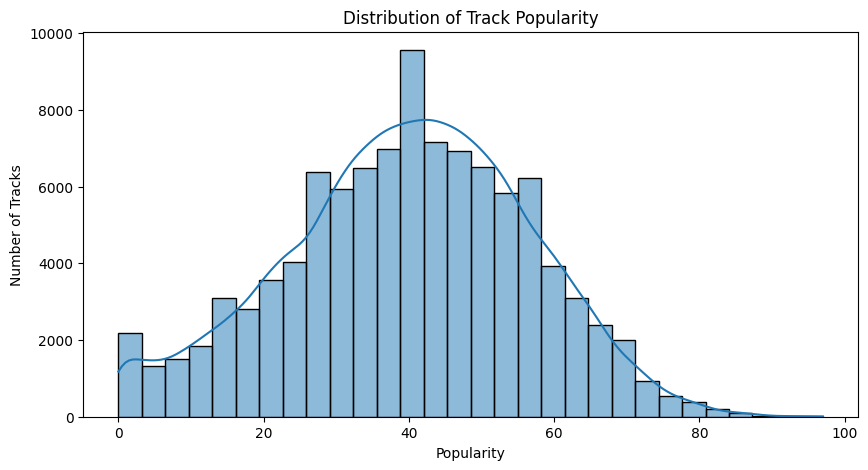

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(tracks["popularity"], bins=30, kde=True)
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.show()

In [9]:
tracks["popularity"].describe()

count    101939.000000
mean         39.782311
std          16.790769
min           0.000000
25%          29.000000
50%          41.000000
75%          52.000000
max          97.000000
Name: popularity, dtype: float64

## 4. Track Type and Country

Since this dataset does not contain an `explicit` column, we instead check basic categorical variables such as track type and country.

In [11]:
tracks["type"].value_counts()

type
track    101939
Name: count, dtype: int64

In [12]:
tracks["country"].value_counts().head(10)

country
AR    50437
FI    30444
BE    21058
Name: count, dtype: int64

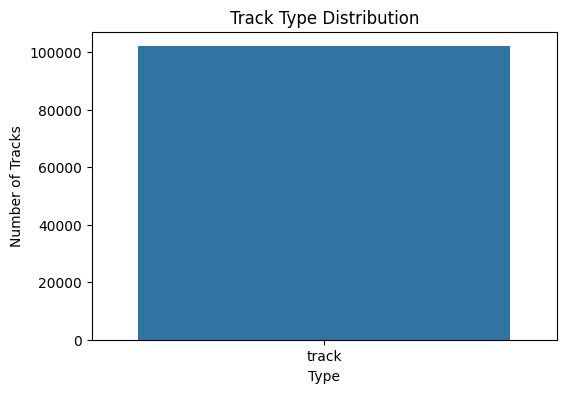

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=tracks, x="type")
plt.title("Track Type Distribution")
plt.xlabel("Type")
plt.ylabel("Number of Tracks")
plt.show()

## 5. Duration Analysis

Track duration is stored in milliseconds, so we convert it into minutes for easier interpretation.

In [14]:
tracks["duration_min"] = tracks["duration_ms"] / 60000

tracks["duration_min"].describe()

count    101939.000000
mean          4.112847
std           3.173838
min           0.019250
25%           3.066667
50%           3.614883
75%           4.350917
max          91.763850
Name: duration_min, dtype: float64

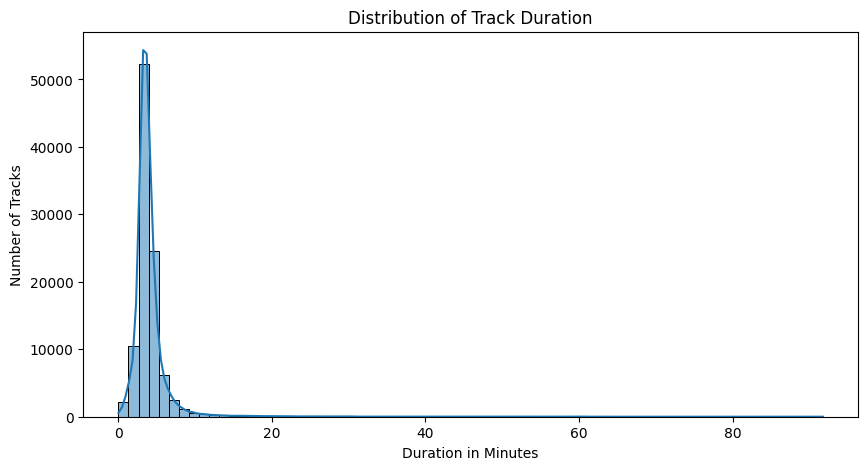

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(tracks["duration_min"], bins=70, kde=True)
plt.title("Distribution of Track Duration")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Tracks")
plt.show()

In [21]:
tracks.sort_values("duration_min", ascending=False)[
    ["name", "duration_min", "popularity"]
].head(10)

,name,duration_min,popularity
48041,A Guide to Men - Helen Rowland,91.763850,17.0
76678,Introductory Lecture to Buddhism,80.192000,12.0
95353,Stadium Hotel,79.516217,9.0
36904,Thanksgiving,78.234000,13.0
44351,The Letters & Journals Of Lord Nelson - Part 1,77.789950,5.0
7190,The Adventure of the Speckled Band,75.138633,10.0
51104,"Thunderstorm, Rain, Ocean Waves - Relaxing Sou...",75.000617,48.0
7194,The Adventure of the Copper Beeches,74.383250,8.0
8370,The Adventure of the Beryl Coronet,73.964867,8.0
26806,Rag Lalit,73.716667,23.0


## 6. Audio-Related Track Features

Some Spotify audio features are already available in the tracks table.  
These variables are important because they may later help describe similarity between songs.

In [22]:
audio_cols = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "loudness"
]

available_audio_cols = [col for col in audio_cols if col in tracks.columns]

available_audio_cols

['danceability',
 'energy',
 'valence',
 'acousticness',
 'instrumentalness',
 'liveness',
 'speechiness',
 'tempo',
 'loudness']

In [23]:
tracks[available_audio_cols].describe()

,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness
count,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000,101939.000000
mean,0.586015,0.586479,0.482813,0.352124,0.148776,0.197640,0.128841,118.358527,-9.462720
std,0.177724,0.260170,0.261690,0.334855,0.304024,0.175391,0.203324,30.224074,6.198508
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000
25%,0.480000,0.411000,0.271000,0.040700,0.000000,0.095600,0.036400,95.973000,-11.149000
50%,0.610000,0.629000,0.477000,0.238000,0.000037,0.124000,0.050600,118.067000,-7.599000
75%,0.714000,0.798000,0.693000,0.645000,0.034400,0.241000,0.104000,136.045000,-5.509000
max,0.989000,1.000000,0.993000,0.996000,1.000000,0.999000,0.969000,244.035000,2.719000


## 7. Audio Feature Distributions

We now inspect the distributions of the main audio-related variables.

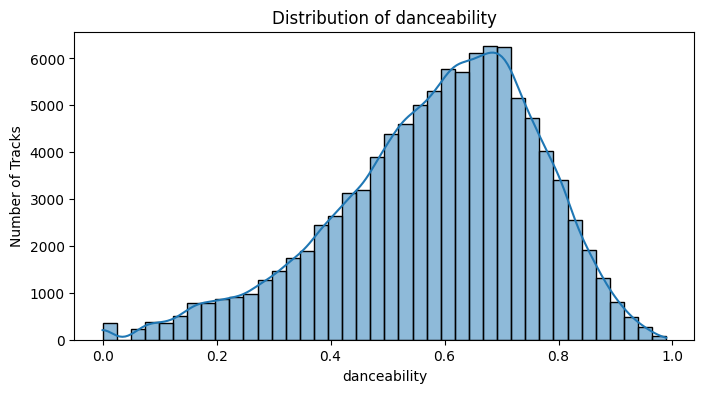

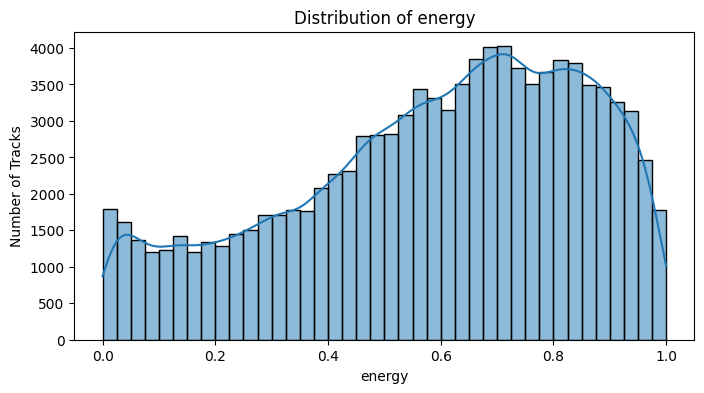

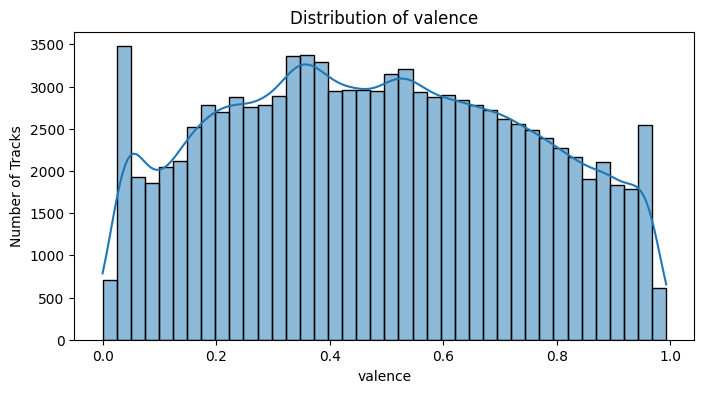

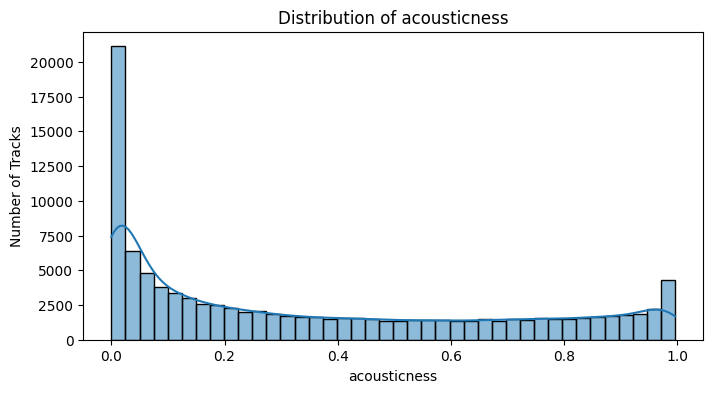

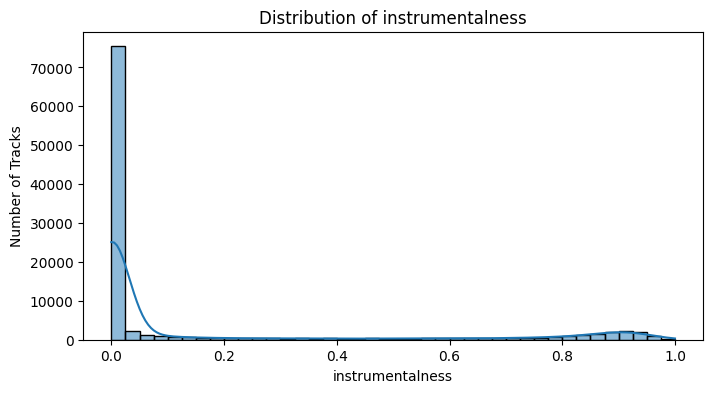

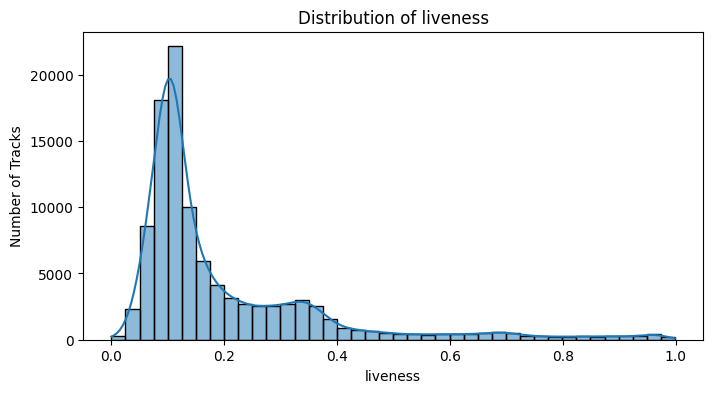

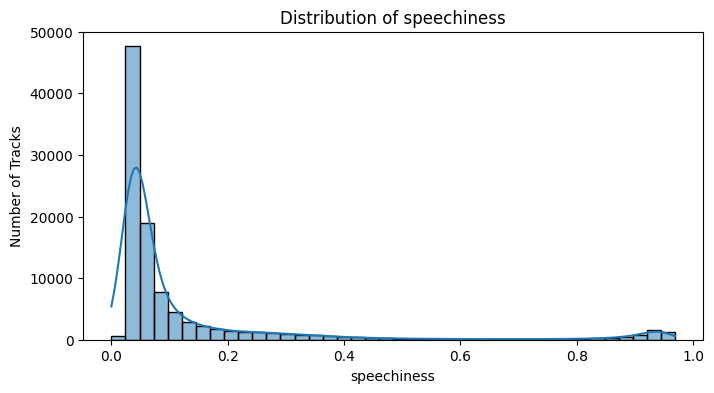

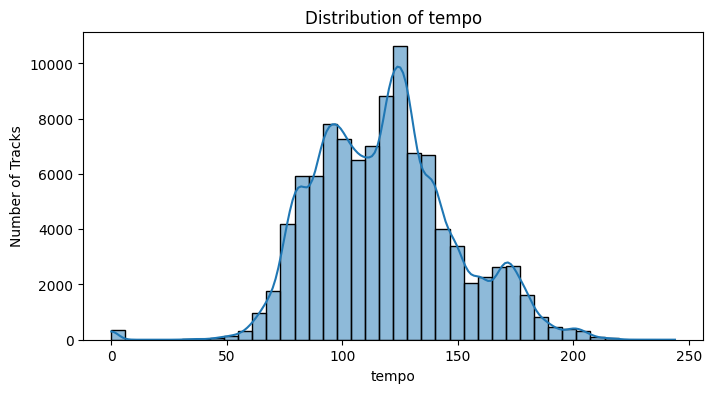

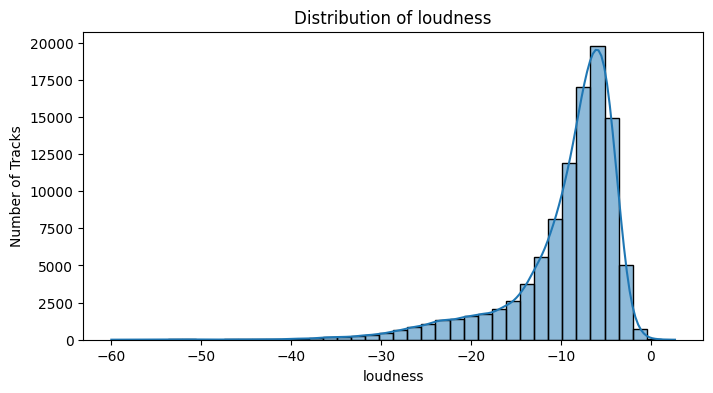

In [24]:
for col in available_audio_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(tracks[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Tracks")
    plt.show()

## 8. Popularity and Audio Features

Here we check how track popularity relates to selected audio features.

In [25]:
selected_cols = ["popularity"] + available_audio_cols

correlation_matrix = tracks[selected_cols].corr(numeric_only=True)

correlation_matrix

,popularity,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness
popularity,1.000000,0.092382,0.153979,0.034412,-0.154408,-0.041537,-0.059116,-0.304212,0.061869,0.239679
danceability,0.092382,1.000000,0.249542,0.524972,-0.270211,-0.286676,-0.073848,0.159351,0.013437,0.345126
energy,0.153979,0.249542,1.000000,0.406321,-0.715392,-0.257773,0.172516,-0.128948,0.221748,0.779383
valence,0.034412,0.524972,0.406321,1.000000,-0.250675,-0.313378,0.033650,0.028572,0.115481,0.377844
acousticness,-0.154408,-0.270211,-0.715392,-0.250675,1.000000,0.209567,-0.028647,0.159875,-0.200139,-0.583019
instrumentalness,-0.041537,-0.286676,-0.257773,-0.313378,0.209567,1.000000,-0.092166,-0.156240,-0.066160,-0.422938
liveness,-0.059116,-0.073848,0.172516,0.033650,-0.028647,-0.092166,1.000000,0.235548,-0.018263,0.045502
speechiness,-0.304212,0.159351,-0.128948,0.028572,0.159875,-0.156240,0.235548,1.000000,-0.088037,-0.234375
tempo,0.061869,0.013437,0.221748,0.115481,-0.200139,-0.066160,-0.018263,-0.088037,1.000000,0.228437
loudness,0.239679,0.345126,0.779383,0.377844,-0.583019,-0.422938,0.045502,-0.234375,0.228437,1.000000


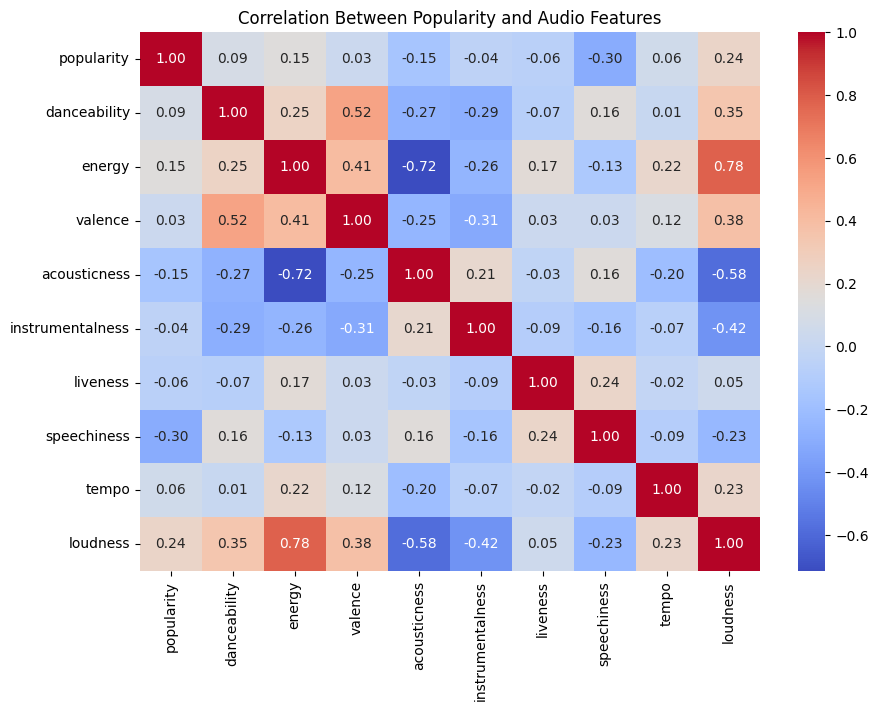

In [26]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Popularity and Audio Features")
plt.show()

## 9. Most Common Artists

The artist information is stored as IDs or list-like values, so this is only a first rough look.  
A cleaner artist analysis will be done later in the artist EDA notebook.

In [33]:
artist_series = (
    tracks["artists_id"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.split(",")
)

artist_exploded = artist_series.explode().str.strip()

artist_counts = artist_exploded.value_counts().head(15)

artist_counts

artists_id
0LyfQWJT6nXafLPZqxe9Of    292
1l6d0RIxTL3JytlLGvWzYe    251
0vLsqW05dyLvjuKKftAEGA    180
49FYG2DSZqIVpCtoir2Upw    162
3iiABQlNuezpR3DcrlyPoA    158
3UbPiAHODPHyrORJPMPnEG    144
5n9GpZoADUf74D92NYi6CN    140
2424G4yH7tJBPlbAoiVmc3    140
2Jc4AEeBTE47KwuKgYOtcL    140
5aIqB5nVVvmFsvSdExz408    132
3t2iKODSDyzoDJw7AsD99u    128
3gBKY0y3dFFVRqicLnVZYz    124
7y97mc3bZRFXzT2szRM4L4    124
6b9DQDp0xKeYM2vdK9pAE6    121
6kACVPfCOnqzgfEF5ryl0x    112
Name: count, dtype: int64

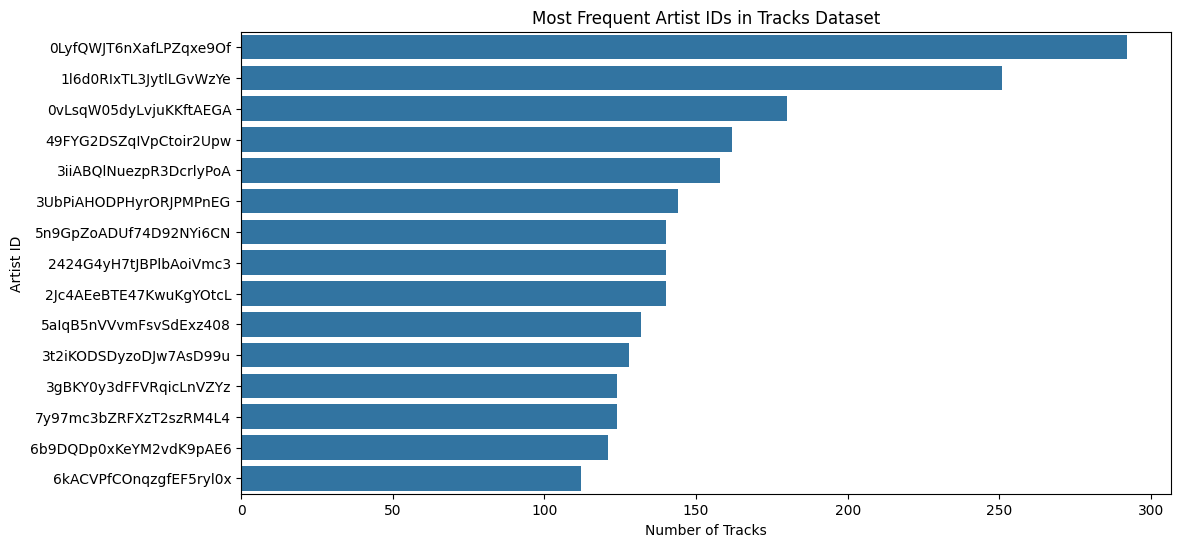

In [34]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=artist_counts.values,
    y=artist_counts.index
)

plt.title("Most Frequent Artist IDs in Tracks Dataset")
plt.xlabel("Number of Tracks")
plt.ylabel("Artist ID")

plt.show()

## 10. Track Name Checks

Here we check whether track names repeat often.  
This does not always mean duplicates, because different songs can have the same name.

In [31]:
tracks["name"].value_counts().head(20)

name
Home           45
You            39
Time           28
Breathe        26
Crazy          26
Alive          25
Drive          25
Dreams         23
With You       23
Hold On        23
Lullaby        22
Summertime     22
Without You    21
Heartbeat      21
Love           20
Fuego          20
Runaway        20
Falling        20
Closer         20
Only You       20
Name: count, dtype: int64

In [32]:
repeated_names = tracks["name"].value_counts()
repeated_names[repeated_names > 1].head(20)

name
Home           45
You            39
Time           28
Breathe        26
Crazy          26
Alive          25
Drive          25
Dreams         23
With You       23
Hold On        23
Lullaby        22
Summertime     22
Without You    21
Heartbeat      21
Love           20
Fuego          20
Runaway        20
Falling        20
Closer         20
Only You       20
Name: count, dtype: int64

## 11. Initial Notes

- The tracks dataset is relatively clean, with no major missing value or duplicate issues detected during the initial checks.
- Most tracks fall into medium popularity ranges, while highly popular songs are less common.
- Track duration is generally around standard song length, although some extreme outliers exist.
- Several audio-related variables show meaningful relationships, especially energy, loudness, acousticness, and valence.
- The dataset already contains many useful numerical features that can later support similarity-based recommendation methods.
- Artist information is currently stored as IDs, so a more detailed artist-level analysis will be handled separately in the artist EDA notebook.
- Repeated track names exist in the dataset, but these do not necessarily represent duplicated songs.

In [35]:
con.close()